### LIBRARY IMPORTS

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import copy
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

if os.getcwd().endswith('notebooks'):
    os.chdir('..')

from src import *
from src.data_manager import DataManager
from src.processor import Processor
from src.nn_regressor import NNRegressor
from src.gb_regressor import GBRegressor

### CONFIGURATION

In [2]:
data_manager = DataManager()

datasets_config, modeling_config = data_manager.load_config()

active_dataset = modeling_config["main"]["active_dataset"]
active_dataset_config = datasets_config[active_dataset]
target = active_dataset_config["target"]

problem_type = active_dataset_config["problem_type"]

gradient_boosting_config = modeling_config["gradient_boosting"]

weak_learner_key = gradient_boosting_config["weak_learner_key"]
weak_learner_config = modeling_config[weak_learner_key]

processor = Processor(**active_dataset_config)

raw_train, raw_test = data_manager.load_raw_data()
raw_train = processor.cut_data(raw_train)

### CROSS-VALIDATION

In [3]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def my_cross_validation(model, data, target, kf, processor):
    mse_scores = []
    r2_scores = []
    oof_preds = np.zeros(len(data))

    for train_idx, valid_idx in kf.split(data):
        train_df = raw_train.iloc[train_idx]
        valid_df = raw_train.iloc[valid_idx]

        train_proc = processor.fit_transform(train_df)
        valid_proc = processor.transform(valid_df)

        X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
        X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

        model.fit(X_train, y_train)

        preds = model.predict(X_valid)
        oof_preds[valid_idx] = preds

        fold_mse = mean_squared_error(y_valid, preds)
        fold_r2 = r2_score(y_valid, preds)
        
        mse_scores.append(fold_mse)
        r2_scores.append(fold_r2)
    
    return mse_scores, r2_scores, oof_preds

### RIDGE REGRESSION

In [4]:
%%time

ridge = Ridge(alpha=1.0, random_state=42)
ridge_mse_scores, ridge_r2_scores, ridge_oof_preds = my_cross_validation(ridge, raw_train, target, kf, processor)

CPU times: total: 1.12 s
Wall time: 1.09 s


In [5]:
print("Ridge MSE scores:", ridge_mse_scores)
print("Ridge R2 scores:", ridge_r2_scores)

Ridge MSE scores: [0.01206151807514626, 0.012292627662309843, 0.012080486735903177, 0.01227748025803125, 0.012255805037537999]
Ridge R2 scores: [0.7801613291103521, 0.7780645197870598, 0.7791724013834471, 0.7769449852617083, 0.7756258485946159]


### DECISION TREE

In [6]:
%%time

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_mse_scores, dt_r2_scores, dt_oof_preds = my_cross_validation(dt, raw_train, target, kf, processor)

CPU times: total: 1.75 s
Wall time: 1.78 s


In [7]:
print("Decision tree MSE scores:", dt_mse_scores)
print("Decision tree R2 scores:", dt_r2_scores)

Decision tree MSE scores: [0.017833131175414893, 0.018043508431977214, 0.01791111399581419, 0.018086290485257433, 0.01804981931225231]
Decision tree R2 scores: [0.6749653044518265, 0.6742360690826752, 0.6725903203479433, 0.6714115839761872, 0.6695514591817715]


### RANDOM FOREST

In [8]:
%%time

rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_mse_scores, rf_r2_scores, rf_oof_preds = my_cross_validation(rf, raw_train, target, kf, processor)

CPU times: total: 48.9 s
Wall time: 49 s


In [9]:
print("Random forest MSE scores:", rf_mse_scores)
print("Random forest R2 scores:", rf_r2_scores)

Random forest MSE scores: [0.01667669954798179, 0.016918746225209624, 0.0168425641186361, 0.016951252744353558, 0.01689960982579473]
Random forest R2 scores: [0.6960429491036638, 0.6945429267653251, 0.6921230849242217, 0.6920327419585197, 0.6906090132691516]


### NEURAL NETWORK

In [10]:
class MLP(NNRegressor):
    def __init__(self, **hyperparameters):
        super().__init__(**hyperparameters)

    def fit(
        self,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_valid: np.ndarray,
        y_valid: np.ndarray, 
        patience: int = 10
    ) -> None:
        
        input_size = X_train.shape[1]
        output_size = y_train.shape[1] if len(y_train.shape) > 1 else 1
        self._get_network(input_size, output_size)
        
        train_loader = self._prepare_loader(X_train, y_train)
        
        X_valid_t = torch.from_numpy(X_valid).to(torch.float32).to(self.device)
        y_valid_t = torch.from_numpy(y_valid).to(torch.float32).view(-1, output_size).to(self.device)

        criterion = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), self.learning_rate)
        
        best_loss = float('inf')
        best_model = None
        early_stop_count = 0

        for epoch in range(self.epochs):
            self.train()
            train_loss = 0
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                
                optimizer.zero_grad()
                preds = self(batch_X)
                loss = criterion(preds, batch_y.view_as(preds))
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            self.eval()
            with torch.no_grad():
                val_preds = self(X_valid_t)
                val_loss = criterion(val_preds, y_valid_t).item()

                val_preds_np = val_preds.cpu().numpy().flatten()
                y_valid_np = y_valid_t.cpu().numpy().flatten()
                val_r2 = r2_score(y_valid_np, val_preds_np)

            if (epoch+1) % 1 == 0:
                print(f"Epoch: {epoch+1} | Validation MSE: {val_loss:.4f} | R^2: {val_r2:.4f}")

            if val_loss < best_loss:
                best_loss = val_loss
                best_model = copy.deepcopy(self.state_dict())
                early_stop_count = 0
            else:
                early_stop_count += 1

            if early_stop_count >= patience:
                print("-"*50)
                break
                
        if best_model:
            self.load_state_dict(best_model)

In [11]:
%%time

mlp = MLP(epochs=100, learning_rate=0.001, hidden_size=[16, 8], batch_size=1024)

mlp_mse_scores = []
mlp_r2_scores = []
mlp_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    mlp.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = mlp.predict(X_valid.values).ravel()
    mlp_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    mlp_mse_scores.append(fold_mse)
    mlp_r2_scores.append(fold_r2)

Epoch: 1 | Validation MSE: 0.0501 | R^2: 0.0869
Epoch: 2 | Validation MSE: 0.0334 | R^2: 0.3916
Epoch: 3 | Validation MSE: 0.0224 | R^2: 0.5909
Epoch: 4 | Validation MSE: 0.0126 | R^2: 0.7702
Epoch: 5 | Validation MSE: 0.0121 | R^2: 0.7793
Epoch: 6 | Validation MSE: 0.0121 | R^2: 0.7795
Epoch: 7 | Validation MSE: 0.0121 | R^2: 0.7795
Epoch: 8 | Validation MSE: 0.0121 | R^2: 0.7793
Epoch: 9 | Validation MSE: 0.0121 | R^2: 0.7787
Epoch: 10 | Validation MSE: 0.0121 | R^2: 0.7793
Epoch: 11 | Validation MSE: 0.0123 | R^2: 0.7762
Epoch: 12 | Validation MSE: 0.0122 | R^2: 0.7778
Epoch: 13 | Validation MSE: 0.0121 | R^2: 0.7792
Epoch: 14 | Validation MSE: 0.0121 | R^2: 0.7797
Epoch: 15 | Validation MSE: 0.0122 | R^2: 0.7784
Epoch: 16 | Validation MSE: 0.0121 | R^2: 0.7788
Epoch: 17 | Validation MSE: 0.0121 | R^2: 0.7792
Epoch: 18 | Validation MSE: 0.0121 | R^2: 0.7792
Epoch: 19 | Validation MSE: 0.0121 | R^2: 0.7795
Epoch: 20 | Validation MSE: 0.0121 | R^2: 0.7797
Epoch: 21 | Validation MSE: 0

In [12]:
print("Neural network MSE scores:", mlp_mse_scores)
print("Neural network R2 scores:", mlp_r2_scores)

Neural network MSE scores: [0.012079044889188111, 0.012291989797406862, 0.012099336251562905, 0.012308429120859913, 0.012268660864510368]
Neural network R2 scores: [0.779841877489098, 0.7780760360273172, 0.7788278380087073, 0.776382711985002, 0.7753904894926471]


### GRADIENT BOOSTING (DTs)

In [13]:
%%time

gb_mse_scores = []
gb_r2_scores = []
gb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    gb = GBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        early_stopping_rounds=10,
        weak_learner_key="decision_tree",
        weak_learner_config={"max_depth": 5, "random_state": 42}
    )
    
    gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = gb.predict(X_valid.values).ravel()
    gb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    gb_mse_scores.append(fold_mse)
    gb_r2_scores.append(fold_r2)
    
    print('-' * 50)

2026-04-25 19:05:05,307 - INFO - Iteration: 10 | Validation MSE: 0.026404 | Validation R^2: 0.518747 
2026-04-25 19:05:06,548 - INFO - Iteration: 20 | Validation MSE: 0.017927 | Validation R^2: 0.673248 
2026-04-25 19:05:07,722 - INFO - Iteration: 30 | Validation MSE: 0.014770 | Validation R^2: 0.730800 
2026-04-25 19:05:08,901 - INFO - Iteration: 40 | Validation MSE: 0.013309 | Validation R^2: 0.757420 
2026-04-25 19:05:10,099 - INFO - Iteration: 50 | Validation MSE: 0.012583 | Validation R^2: 0.770649 
2026-04-25 19:05:11,377 - INFO - Iteration: 60 | Validation MSE: 0.012244 | Validation R^2: 0.776828 
2026-04-25 19:05:12,600 - INFO - Iteration: 70 | Validation MSE: 0.012086 | Validation R^2: 0.779720 
2026-04-25 19:05:13,760 - INFO - Iteration: 80 | Validation MSE: 0.012006 | Validation R^2: 0.781178 
2026-04-25 19:05:14,960 - INFO - Iteration: 90 | Validation MSE: 0.011961 | Validation R^2: 0.781985 
2026-04-25 19:05:16,176 - INFO - Iteration: 100 | Validation MSE: 0.011934 | Valid

--------------------------------------------------


2026-04-25 19:05:28,215 - INFO - Iteration: 10 | Validation MSE: 0.026924 | Validation R^2: 0.513909 
2026-04-25 19:05:29,438 - INFO - Iteration: 20 | Validation MSE: 0.018820 | Validation R^2: 0.660213 
2026-04-25 19:05:30,702 - INFO - Iteration: 30 | Validation MSE: 0.015273 | Validation R^2: 0.724254 
2026-04-25 19:05:31,973 - INFO - Iteration: 40 | Validation MSE: 0.013606 | Validation R^2: 0.754361 
2026-04-25 19:05:33,296 - INFO - Iteration: 50 | Validation MSE: 0.012844 | Validation R^2: 0.768101 
2026-04-25 19:05:34,686 - INFO - Iteration: 60 | Validation MSE: 0.012475 | Validation R^2: 0.774779 
2026-04-25 19:05:36,034 - INFO - Iteration: 70 | Validation MSE: 0.012305 | Validation R^2: 0.777846 
2026-04-25 19:05:37,429 - INFO - Iteration: 80 | Validation MSE: 0.012217 | Validation R^2: 0.779439 
2026-04-25 19:05:38,795 - INFO - Iteration: 90 | Validation MSE: 0.012172 | Validation R^2: 0.780245 
2026-04-25 19:05:40,079 - INFO - Iteration: 100 | Validation MSE: 0.012149 | Valid

--------------------------------------------------


2026-04-25 19:05:53,961 - INFO - Iteration: 10 | Validation MSE: 0.028058 | Validation R^2: 0.487108 
2026-04-25 19:05:55,142 - INFO - Iteration: 20 | Validation MSE: 0.019259 | Validation R^2: 0.647942 
2026-04-25 19:05:56,316 - INFO - Iteration: 30 | Validation MSE: 0.015207 | Validation R^2: 0.722022 
2026-04-25 19:05:57,545 - INFO - Iteration: 40 | Validation MSE: 0.013395 | Validation R^2: 0.755135 
2026-04-25 19:05:58,774 - INFO - Iteration: 50 | Validation MSE: 0.012636 | Validation R^2: 0.769013 
2026-04-25 19:06:00,003 - INFO - Iteration: 60 | Validation MSE: 0.012306 | Validation R^2: 0.775046 
2026-04-25 19:06:01,194 - INFO - Iteration: 70 | Validation MSE: 0.012139 | Validation R^2: 0.778101 
2026-04-25 19:06:02,426 - INFO - Iteration: 80 | Validation MSE: 0.012056 | Validation R^2: 0.779617 
2026-04-25 19:06:03,589 - INFO - Iteration: 90 | Validation MSE: 0.012011 | Validation R^2: 0.780441 
2026-04-25 19:06:04,776 - INFO - Iteration: 100 | Validation MSE: 0.011981 | Valid

--------------------------------------------------


2026-04-25 19:06:30,321 - INFO - Iteration: 10 | Validation MSE: 0.027268 | Validation R^2: 0.504593 
2026-04-25 19:06:31,550 - INFO - Iteration: 20 | Validation MSE: 0.017935 | Validation R^2: 0.674162 
2026-04-25 19:06:32,803 - INFO - Iteration: 30 | Validation MSE: 0.014758 | Validation R^2: 0.731877 
2026-04-25 19:06:33,949 - INFO - Iteration: 40 | Validation MSE: 0.013469 | Validation R^2: 0.755304 
2026-04-25 19:06:35,134 - INFO - Iteration: 50 | Validation MSE: 0.012821 | Validation R^2: 0.767077 
2026-04-25 19:06:36,320 - INFO - Iteration: 60 | Validation MSE: 0.012494 | Validation R^2: 0.773005 
2026-04-25 19:06:37,607 - INFO - Iteration: 70 | Validation MSE: 0.012321 | Validation R^2: 0.776150 
2026-04-25 19:06:38,767 - INFO - Iteration: 80 | Validation MSE: 0.012233 | Validation R^2: 0.777757 
2026-04-25 19:06:39,962 - INFO - Iteration: 90 | Validation MSE: 0.012187 | Validation R^2: 0.778597 
2026-04-25 19:06:41,136 - INFO - Iteration: 100 | Validation MSE: 0.012156 | Valid

--------------------------------------------------


2026-04-25 19:07:02,360 - INFO - Iteration: 10 | Validation MSE: 0.029318 | Validation R^2: 0.463254 
2026-04-25 19:07:03,585 - INFO - Iteration: 20 | Validation MSE: 0.018950 | Validation R^2: 0.653066 
2026-04-25 19:07:04,835 - INFO - Iteration: 30 | Validation MSE: 0.014896 | Validation R^2: 0.727290 
2026-04-25 19:07:06,098 - INFO - Iteration: 40 | Validation MSE: 0.013351 | Validation R^2: 0.755580 
2026-04-25 19:07:07,286 - INFO - Iteration: 50 | Validation MSE: 0.012724 | Validation R^2: 0.767063 
2026-04-25 19:07:08,519 - INFO - Iteration: 60 | Validation MSE: 0.012419 | Validation R^2: 0.772630 
2026-04-25 19:07:09,741 - INFO - Iteration: 70 | Validation MSE: 0.012265 | Validation R^2: 0.775452 
2026-04-25 19:07:10,960 - INFO - Iteration: 80 | Validation MSE: 0.012189 | Validation R^2: 0.776850 
2026-04-25 19:07:12,240 - INFO - Iteration: 90 | Validation MSE: 0.012152 | Validation R^2: 0.777534 
2026-04-25 19:07:13,733 - INFO - Iteration: 100 | Validation MSE: 0.012133 | Valid

--------------------------------------------------
CPU times: total: 2min 35s
Wall time: 2min 35s


In [14]:
print("DT GB MSE scores:", gb_mse_scores)
print("DT GB R2 scores:", gb_r2_scores)

DT GB MSE scores: [0.011878676641184622, 0.012083558159669116, 0.011863711436714794, 0.012040271856209586, 0.012038104481299185]
DT GB R2 scores: [0.7834938795882649, 0.7818391350882876, 0.783134987478334, 0.7812545441005235, 0.779611419303105]


### XGBOOST

In [15]:
%%time

xgb_mse_scores = []
xgb_r2_scores = []
xgb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    xgb = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        early_stopping_rounds=10,
        max_depth=5,
        random_state=42
    )
    
    xgb.fit(X_train.values, y_train.values, eval_set=[(X_valid.values, y_valid.values)], verbose=False)

    preds = xgb.predict(X_valid.values).ravel()
    xgb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    xgb_mse_scores.append(fold_mse)
    xgb_r2_scores.append(fold_r2)

CPU times: total: 39 s
Wall time: 4.05 s


In [16]:
print("XGB MSE scores:", xgb_mse_scores)
print("XGB R2 scores:", xgb_r2_scores)

XGB MSE scores: [0.011930961991932748, 0.012125256178798262, 0.011950625824619332, 0.012096604777237238, 0.012137645057250722]
XGB R2 scores: [0.7825409031931002, 0.7810863041921131, 0.7815462190796945, 0.7802310978993493, 0.7777890720814314]


### GRADIENT BOOSTING (NNs)

In [17]:
%%time

nn_gb_mse_scores = []
nn_gb_r2_scores = []
nn_gb_oof_preds = np.zeros(len(raw_train))

for train_idx, valid_idx in kf.split(raw_train):
    train_df = raw_train.iloc[train_idx]
    valid_df = raw_train.iloc[valid_idx]

    train_proc = processor.fit_transform(train_df)
    valid_proc = processor.transform(valid_df)

    X_train, y_train = train_proc.drop(columns=[target]), train_proc[target]
    X_valid, y_valid = valid_proc.drop(columns=[target]), valid_proc[target]

    nn_gb = GBRegressor(
        n_estimators=1000,
        learning_rate=0.5,
        subsample=1.0,
        colsample_bytree=1.0,
        reg_lambda=0.5,
        early_stopping_rounds=10,
        weak_learner_key="neural_network",
        weak_learner_config={
            "epochs": 10,
            "learning_rate": 0.001,
            "hidden_size": [16, 8],
            "batch_size": 1024
        }
    )

    nn_gb.fit(X_train.values, y_train.values, X_valid.values, y_valid.values)

    preds = nn_gb.predict(X_valid.values).ravel()
    nn_gb_oof_preds[valid_idx] = preds

    fold_mse = mean_squared_error(y_valid, preds)
    fold_r2 = r2_score(y_valid, preds)
    
    nn_gb_mse_scores.append(fold_mse)
    nn_gb_r2_scores.append(fold_r2)
    
    print('-' * 50)

2026-04-25 19:08:55,492 - INFO - Iteration: 10 | Validation MSE: 0.012034 | Validation R^2: 0.780658 
2026-04-25 19:10:07,244 - INFO - Iteration: 20 | Validation MSE: 0.012046 | Validation R^2: 0.780439 
2026-04-25 19:10:07,245 - INFO - Early stopping triggered at iteration 20. Best iteration: 10


--------------------------------------------------


2026-04-25 19:11:18,798 - INFO - Iteration: 10 | Validation MSE: 0.012324 | Validation R^2: 0.777498 
2026-04-25 19:12:30,364 - INFO - Iteration: 20 | Validation MSE: 0.012315 | Validation R^2: 0.777662 
2026-04-25 19:13:05,923 - INFO - Early stopping triggered at iteration 25. Best iteration: 15


--------------------------------------------------


2026-04-25 19:14:21,403 - INFO - Iteration: 10 | Validation MSE: 0.012066 | Validation R^2: 0.779433 
2026-04-25 19:15:29,137 - INFO - Early stopping triggered at iteration 19. Best iteration: 9


--------------------------------------------------


2026-04-25 19:16:41,364 - INFO - Iteration: 10 | Validation MSE: 0.012268 | Validation R^2: 0.777110 
2026-04-25 19:17:46,633 - INFO - Early stopping triggered at iteration 19. Best iteration: 9


--------------------------------------------------


2026-04-25 19:18:59,232 - INFO - Iteration: 10 | Validation MSE: 0.012256 | Validation R^2: 0.775618 
2026-04-25 19:19:56,796 - INFO - Early stopping triggered at iteration 18. Best iteration: 8


--------------------------------------------------
CPU times: total: 29min 43s
Wall time: 12min 13s


In [18]:
print("NN GB MSE scores:", nn_gb_mse_scores)
print("NN GB R2 scores:", nn_gb_r2_scores)

NN GB MSE scores: [0.012034285282824625, 0.012302970112939715, 0.012065351520707913, 0.01226319323046905, 0.012246964039706097]
NN GB R2 scores: [0.7806576862713083, 0.7778777934979233, 0.7794490684829757, 0.7772045493641526, 0.7757877058842867]


### VISUALIZATION (BY MEAN)

C:\Users\oriol\AppData\Local\Temp\ipykernel_15380\4002622447.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


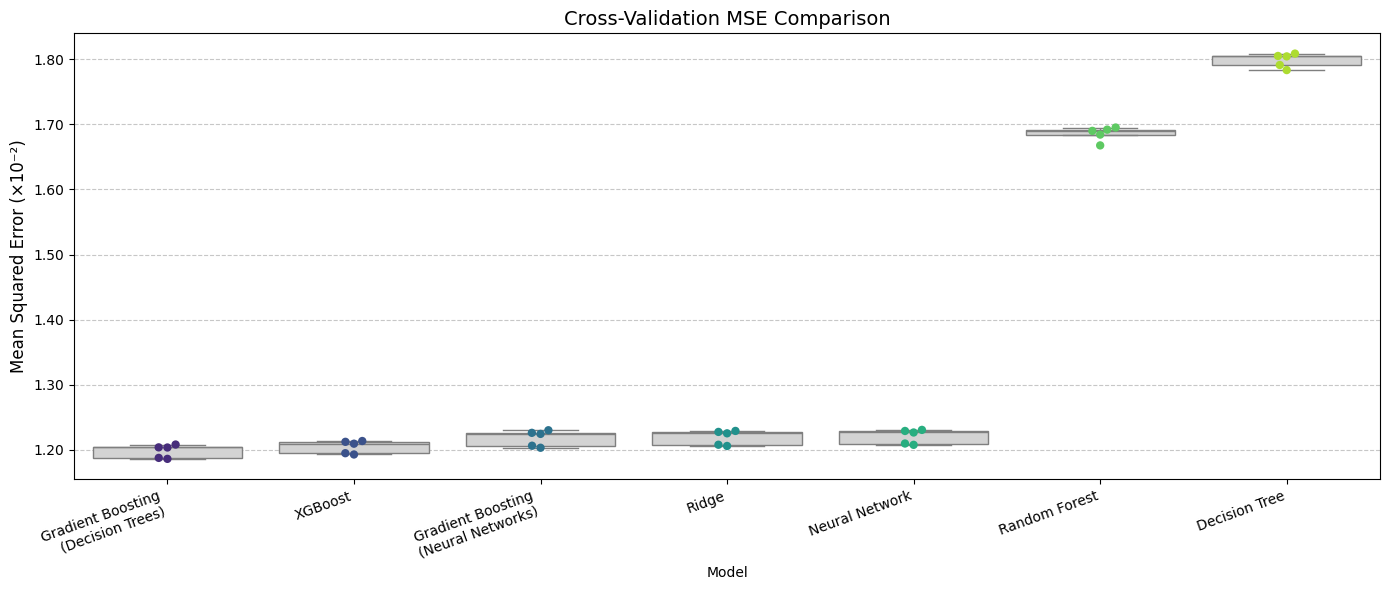

In [19]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Decision Tree': dt_mse_scores,
    'Random Forest': rf_mse_scores,
    'Neural Network': mlp_mse_scores,
    "GB (Decision Trees)": gb_mse_scores,
    'XGBoost': xgb_mse_scores,
    'GB (Neural Networks)': nn_gb_mse_scores
})

melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean MSE (best → worst)
model_order = (
    melted_df.groupby('Model')['MSE']
    .mean()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-2 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e2:.2f}'))
plt.ylabel('Mean Squared Error (×10⁻²)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_15380\2374248617.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


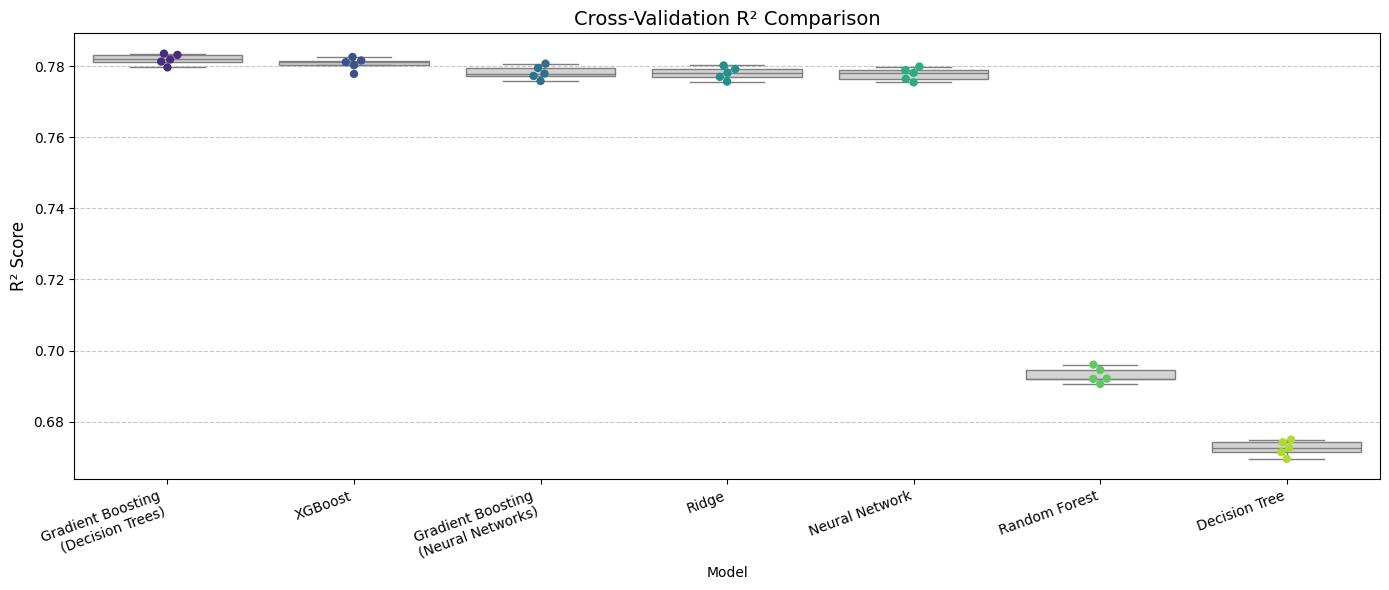

In [20]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_r2_scores,
    'Decision Tree': dt_r2_scores,
    'Random Forest': rf_r2_scores,
    'Neural Network': mlp_r2_scores,
    "GB (Decision Trees)": gb_r2_scores,
    'XGBoost': xgb_r2_scores,
    'GB (Neural Networks)': nn_gb_r2_scores
})

melted_df = results_df.melt(var_name='Model', value_name='R2')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean R² (best → worst = descending)
model_order = (
    melted_df.groupby('Model')['R2']
    .mean()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation R² Comparison', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### VISUALIZATION (BY MEDIAN)

C:\Users\oriol\AppData\Local\Temp\ipykernel_15380\1612917705.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


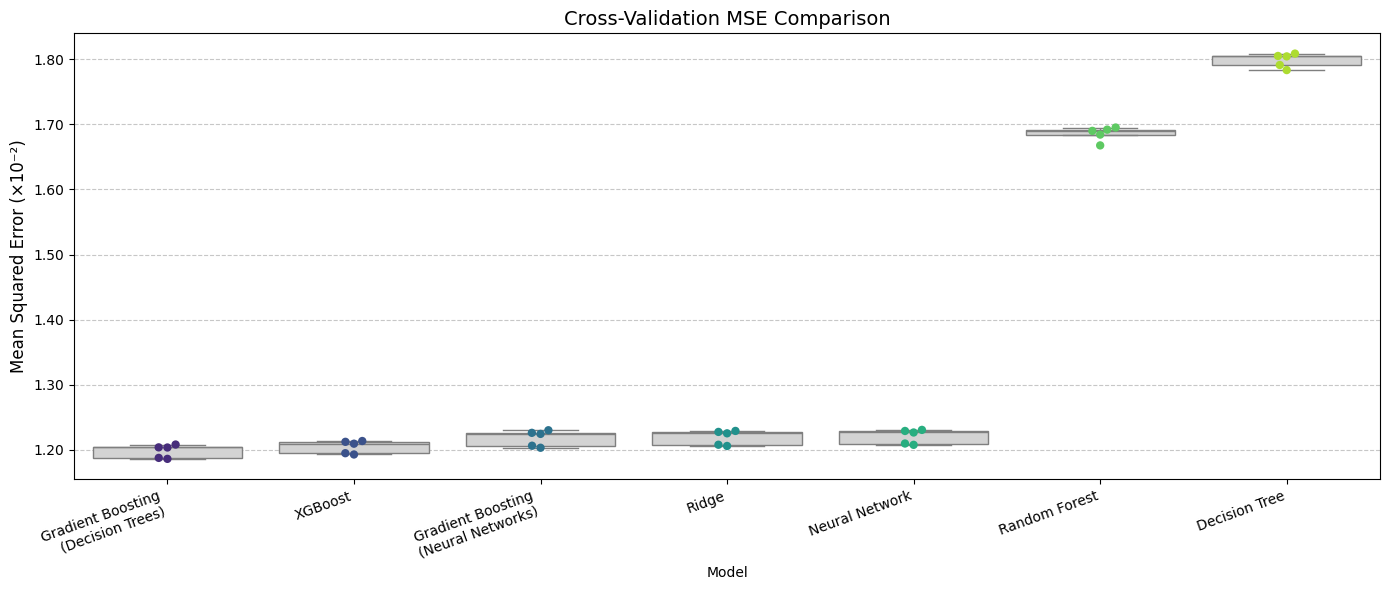

In [21]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Decision Tree': dt_mse_scores,
    'Random Forest': rf_mse_scores,
    'Neural Network': mlp_mse_scores,
    "GB (Decision Trees)": gb_mse_scores,
    'XGBoost': xgb_mse_scores,
    'GB (Neural Networks)': nn_gb_mse_scores
})

melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean MSE (best → worst)
model_order = (
    melted_df.groupby('Model')['MSE']
    .median()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-2 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e2:.2f}'))
plt.ylabel('Mean Squared Error (×10⁻²)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_15380\1894387692.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


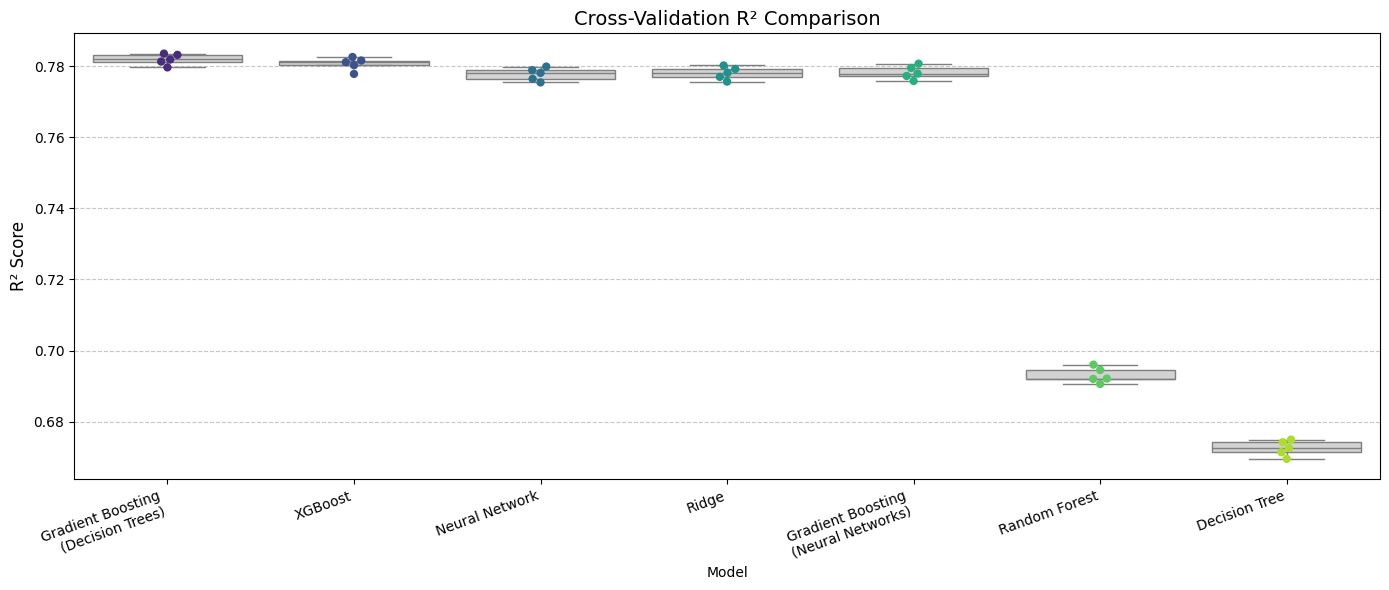

In [22]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_r2_scores,
    'Decision Tree': dt_r2_scores,
    'Random Forest': rf_r2_scores,
    'Neural Network': mlp_r2_scores,
    "GB (Decision Trees)": gb_r2_scores,
    'XGBoost': xgb_r2_scores,
    'GB (Neural Networks)': nn_gb_r2_scores
})

melted_df = results_df.melt(var_name='Model', value_name='R2')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean R² (best → worst = descending)
model_order = (
    melted_df.groupby('Model')['R2']
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation R² Comparison', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### VISUALIZATION (WITHOUT DTs AND RFs)

C:\Users\oriol\AppData\Local\Temp\ipykernel_15380\2935190585.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


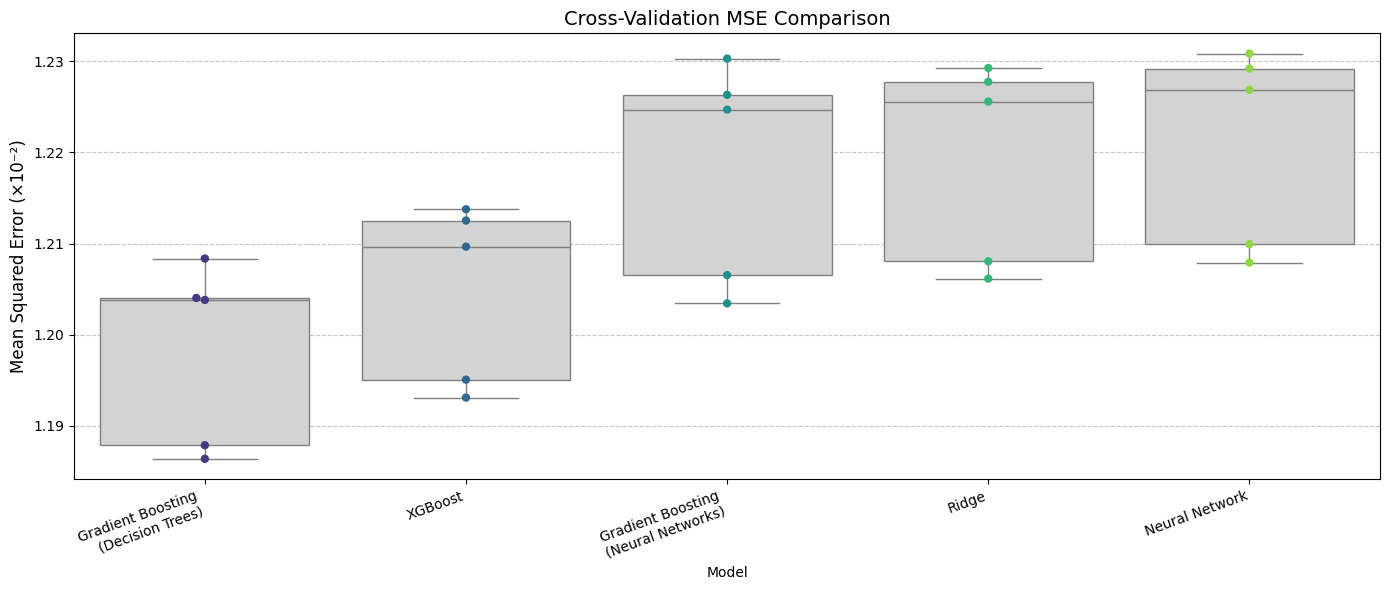

In [23]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_mse_scores,
    'Neural Network': mlp_mse_scores,
    "GB (Decision Trees)": gb_mse_scores,
    'XGBoost': xgb_mse_scores,
    'GB (Neural Networks)': nn_gb_mse_scores
})

melted_df = results_df.melt(var_name='Model', value_name='MSE')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean MSE (best → worst)
model_order = (
    melted_df.groupby('Model')['MSE']
    .median()
    .sort_values()
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='MSE',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Y-axis in 10^-2 scale
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x*1e2:.2f}'))
plt.ylabel('Mean Squared Error (×10⁻²)', fontsize=12)

# 6. Clean styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation MSE Comparison', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

C:\Users\oriol\AppData\Local\Temp\ipykernel_15380\3608224838.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(


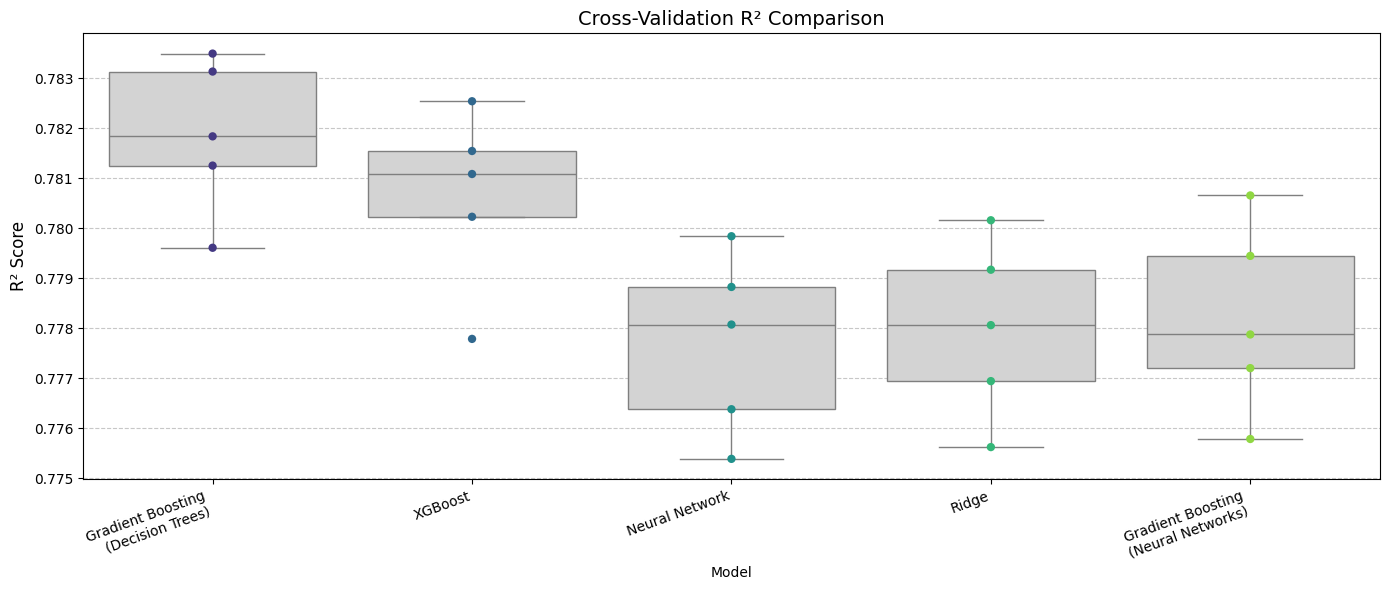

In [24]:
# 1. Prepare data
results_df = pd.DataFrame({
    'Ridge': ridge_r2_scores,
    'Neural Network': mlp_r2_scores,
    "GB (Decision Trees)": gb_r2_scores,
    'XGBoost': xgb_r2_scores,
    'GB (Neural Networks)': nn_gb_r2_scores
})

melted_df = results_df.melt(var_name='Model', value_name='R2')

# 2. Rename with clean multi-line labels
melted_df['Model'] = melted_df['Model'].replace({
    "GB (Decision Trees)": "Gradient Boosting\n(Decision Trees)",
    "GB (Neural Networks)": "Gradient Boosting\n(Neural Networks)"
})

# 3. Order models by mean R² (best → worst = descending)
model_order = (
    melted_df.groupby('Model')['R2']
    .median()
    .sort_values(ascending=False)
    .index
)

# 4. Plot
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    color='lightgray',
    showfliers=False
)

sns.swarmplot(
    data=melted_df,
    x='Model',
    y='R2',
    order=model_order,
    palette='viridis',
    size=6
)

# 5. Styling
plt.xticks(rotation=20, ha='right')
plt.title('Cross-Validation R² Comparison', fontsize=14)
plt.ylabel('R² Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()